<a href="https://colab.research.google.com/github/uyenndt1210/thuchanh-deeplearning/blob/main/Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Tải bộ dữ liệu CIFAR10 có sẵn trong tensorflow
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Ép phẳng nhãn thành mảng 1 chiều để xử lý không bị lỗi format
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Kích thước dữ liệu ban đầu:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Kích thước dữ liệu ban đầu:
X_train: (50000, 32, 32, 3) y_train: (50000,)
X_test: (10000, 32, 32, 3) y_test: (10000,)


In [3]:
print("=== BƯỚC 1: XỬ LÝ DỮ LIỆU ===")

# 1. Reshape dữ liệu từ 4-D (ảnh 3D) thành 2-D array (duỗi phẳng ảnh)
X_train_flat = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test_flat = X_test.reshape(X_test.shape[0], 32 * 32 * 3)

# 2. Chuẩn hóa tính năng (Feature Scaling) về đoạn [0, 1]
minmax = MinMaxScaler()
X_train_scaled = minmax.fit_transform(X_train_flat)
X_test_scaled = minmax.transform(X_test_flat)

# Định nghĩa danh sách các nhãn của CIFAR10 để tiện đối chiếu
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print('Số lượng lớp (Classes):', len(np.unique(y_train)))
print('Các nhãn mã hóa:', np.unique(y_train))

=== BƯỚC 1: XỬ LÝ DỮ LIỆU ===
Số lượng lớp (Classes): 10
Các nhãn mã hóa: [0 1 2 3 4 5 6 7 8 9]


=== BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU ===


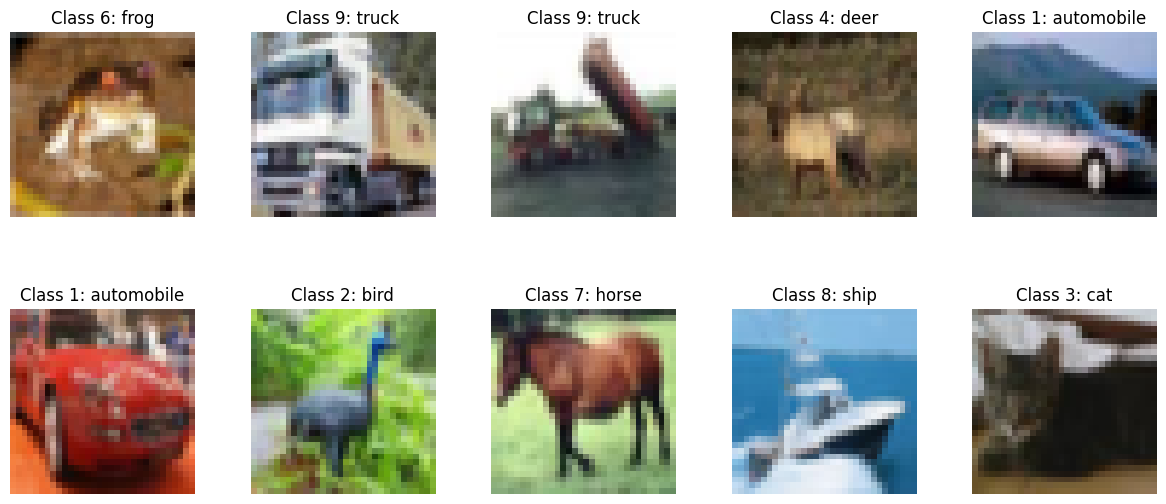

In [4]:
print("=== BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU ===")
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i]) # Hiển thị ảnh màu gốc chưa reshape
    ax[i].title.set_text(f"Class {y_train[i]}: {class_names[y_train[i]]}")
    ax[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [18]:
print("=== BƯỚC 3: XÂY DỰNG MÔ HÌNH ANN THEO YÊU CẦU ===")

# Khởi tạo mô hình mạng neural tuần tự
model = Sequential()

# Tầng ẩn 1: 512 units
model.add(Dense(input_dim=X_train_scaled.shape[1], units=512, kernel_initializer='uniform', activation='relu'))

# Tầng ẩn 2: 256 units
model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))

# Tầng ẩn 3: 128 units
model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Tầng đầu ra
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc tổng quan của mạng mới
model.summary()

=== BƯỚC 3: XÂY DỰNG MÔ HÌNH ANN THEO YÊU CẦU ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

=== BƯỚC 4: HUẤN LUYỆN MÔ HÌNH ===
Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.3000 - loss: 1.8982 - val_accuracy: 0.3588 - val_loss: 1.7776
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.3779 - loss: 1.7196 - val_accuracy: 0.4002 - val_loss: 1.6724
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.4113 - loss: 1.6313 - val_accuracy: 0.4324 - val_loss: 1.5989
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.4352 - loss: 1.5691 - val_accuracy: 0.4272 - val_loss: 1.5883
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4506 - loss: 1.5234 - val_accuracy: 0.4518 - val_loss: 1.5266
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.4677 - loss: 1.4821 - val_accuracy: 0.4610 - val_loss: 1.5329
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4751 - loss: 1.4580 - val_accuracy: 0.4758 - val_loss: 1.4754
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━

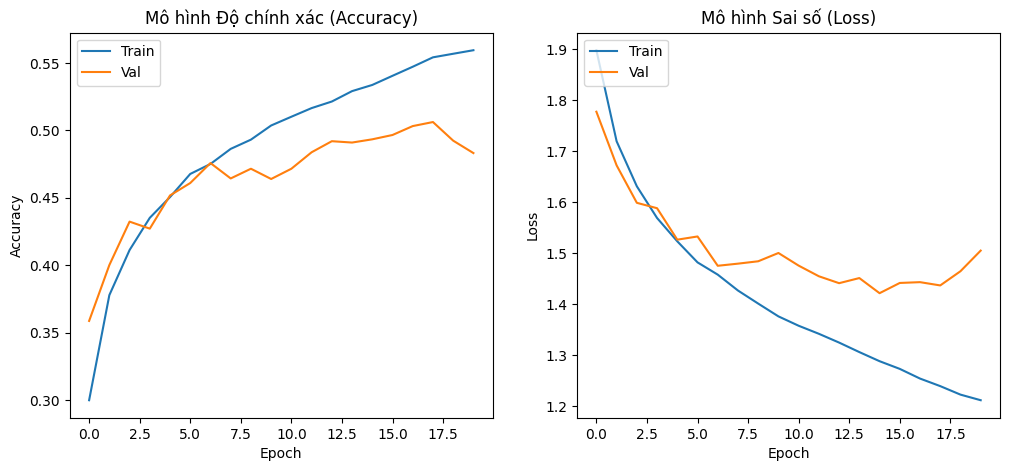

In [19]:
print("=== BƯỚC 4: HUẤN LUYỆN MÔ HÌNH ===")
# Tiến hành fit dữ liệu học
model_fit = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=20, verbose=1)


# --- TRỰC QUAN HÓA ĐỘ CHÍNH XÁC (ACCURACY) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# --- TRỰC QUAN HÓA SAI SỐ (LOSS) ---
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình Sai số (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

In [20]:
print("=== BƯỚC 5: DỰ BÁO ẢNH NGẪU NHIÊN ===")

# Chọn dự báo thử 3 tấm ảnh ở vị trí Index 0, 10 và 50 trong tập Test
test_indices = [0, 10, 50]

for idx in test_indices:
    # Lấy dữ liệu đã scale đưa vào dự đoán
    sample_data = X_test_scaled[idx].reshape(1, -1)
    prediction = model.predict(sample_data)

    # Tìm nhãn có xác suất cao nhất bằng hàm np.argmax
    predicted_label = np.argmax(prediction)
    true_label = y_test[idx]

    print(f"\n[Ảnh tại Index {idx}]:")
    print(f"-> Mô hình dự đoán là: Lớp {predicted_label} ({class_names[predicted_label]})")
    print(f"-> Nhãn thực tế gốc là: Lớp {true_label} ({class_names[true_label]})")

=== BƯỚC 5: DỰ BÁO ẢNH NGẪU NHIÊN ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

[Ảnh tại Index 0]:
-> Mô hình dự đoán là: Lớp 3 (cat)
-> Nhãn thực tế gốc là: Lớp 3 (cat)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

[Ảnh tại Index 10]:
-> Mô hình dự đoán là: Lớp 8 (ship)
-> Nhãn thực tế gốc là: Lớp 0 (airplane)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

[Ảnh tại Index 50]:
-> Mô hình dự đoán là: Lớp 9 (truck)
-> Nhãn thực tế gốc là: Lớp 9 (truck)



=== BƯỚC 6: DỰ BÁO ẢNH TỪ TRÊN MẠNG ===


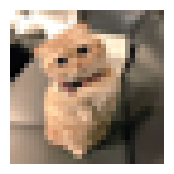


🎯 KẾT QUẢ: Lớp 3 (cat) - Độ tự tin: 49.35%

╒══════════╤════════════════════╤════════════════╤═════════════════════╕
│   Mã Lớp │ Tên Nhãn (Label)   │ Xác Suất (%)   │ Biểu Đồ Trực Quan   │
╞══════════╪════════════════════╪════════════════╪═════════════════════╡
│        0 │ airplane           │ 0.0012 %       │ ░░░░░░░░░░          │
├──────────┼────────────────────┼────────────────┼─────────────────────┤
│        1 │ automobile         │ 0.0749 %       │ ░░░░░░░░░░          │
├──────────┼────────────────────┼────────────────┼─────────────────────┤
│        2 │ bird               │ 2.4500 %       │ ░░░░░░░░░░          │
├──────────┼────────────────────┼────────────────┼─────────────────────┤
│        3 │ ⭐ cat             │ 49.3504 %      │ ████░░░░░░          │
├──────────┼────────────────────┼────────────────┼─────────────────────┤
│        4 │ deer               │ 0.7578 %       │ ░░░░░░░░░░          │
├──────────┼────────────────────┼────────────────┼─────────────────────┤
│      

In [40]:
import requests
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate  # Nhớ chạy dòng này để vẽ bảng nha

print("\n=== BƯỚC 6: DỰ BÁO ẢNH TỪ TRÊN MẠNG ===")

# 1. Đường dẫn URL tấm ảnh muốn test
url_anh = "https://i.pinimg.com/474x/f8/45/68/f8456800ac55a50acda33ea6b9267e54.jpg"

# 2. Tải ảnh và chuyển về ảnh màu RGB chuẩn
response = requests.get(url_anh, headers={'User-Agent': 'Mozilla/5.0'})
img_raw = Image.open(io.BytesIO(response.content))
img_rgb = img_raw.convert('RGB')

# 3. Đổi kích thước về 32x32 của bộ CIFAR-10
img_resized = img_rgb.resize((32, 32))

# 4. Hiển thị ảnh lên màn hình
plt.figure(figsize=(2, 2))
plt.imshow(img_resized)
plt.axis('off')
plt.show()

# 5. Tiền xử lý dữ liệu (Scale về đoạn [0, 1] và duỗi phẳng thành 3072 phần tử)
img_array = np.array(img_resized)
img_scaled = img_array.astype('float32') / 255.0
img_flatten = img_scaled.reshape(1, 32 * 32 * 3)

# 6. Đưa vào mô hình để dự đoán
prediction_url = model.predict(img_flatten, verbose=0)
predicted_label_url = np.argmax(prediction_url)
confidence = prediction_url[0][predicted_label_url] * 100

# 7. In kết quả dự đoán cao nhất
print(f"\n🎯 KẾT QUẢ: Lớp {predicted_label_url} ({class_names[predicted_label_url]}) - Độ tự tin: {confidence:.2f}%\n")

# 8. Tạo dữ liệu để in bảng xác suất 10 lớp kèm thanh biểu đồ cho đẹp
table_data = []
for i, prob in enumerate(prediction_url[0]):
    prob_pct = prob * 100
    progress_bar = "█" * int(prob_pct / 10) + "░" * (10 - int(prob_pct / 10))
    label_text = f"⭐ {class_names[i]}" if i == predicted_label_url else f"  {class_names[i]}"
    table_data.append([i, label_text, f"{prob_pct:>7.4f} %", progress_bar])

# In bảng ra màn hình
headers_table = ["Mã Lớp", "Tên Nhãn (Label)", "Xác Suất (%)", "Biểu Đồ Trực Quan"]
print(tabulate(table_data, headers=headers_table, tablefmt="fancy_grid"))